# Analyse finale — Prévision de la consommation électrique

## Comparaison de M1, M2, M3 et M4

Ce notebook constitue la synthèse finale de la modélisation sur le **dataset final 2016–2025**.

Il ne sert pas à sélectionner de nouveaux hyperparamètres et ne réentraîne pas les modèles. Il analyse les résultats déjà gelés :

- **M1** : régression linéaire, calendrier + retards disponibles ;
- **M2** : M1 + météo observée disponible à l'origine ;
- **M3** : HistGradientBoostingRegressor sur les variables de M2 ;
- **M4** : correction ARMA des erreurs de M1.

### Protocole

- apprentissage : 2016–2022 ;
- validation : 2023 ;
- test final : 2024–2025 ;
- sélection des configurations uniquement sur 2023 ;
- résultats 2024–2025 utilisés uniquement pour l'évaluation finale ;
- journées DST exclues de l'évaluation finale conformément au dataset construit.

L'objectif de ce notebook est de vérifier le dataset final, comparer les quatre modèles sous plusieurs angles et produire les figures nécessaires au rapport.

In [55]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

RACINE = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DATA = RACINE / "data"
RESULTATS = DATA / "resultats"
DATASET = DATA / "donnees-preparees" / "dataset_modelisation_2016_2025.csv"

if not DATASET.exists():
    raise FileNotFoundError(f"Dataset final introuvable : {DATASET}")

print("Racine :", RACINE.resolve())
print("Dataset :", DATASET)
print("Résultats :", RESULTATS)

Racine : C:\Users\DELL 7280\OneDrive\Desktop\Master2 MALIA\Series temporelles\Projet\Projet-series-temporelles
Dataset : ..\data\donnees-preparees\dataset_modelisation_2016_2025.csv
Résultats : ..\data\resultats


## 1. Contrôle du dataset final

In [56]:
df = pd.read_csv(DATASET)
df["jour_cible"] = pd.to_datetime(df["jour_cible"])

print("Dimensions :", df.shape)
print("Période :", df["jour_cible"].min(), "->", df["jour_cible"].max())
print("Nombre total de NaN :", int(df.isna().sum().sum()))
print("Doublons jour/heure :", int(df.duplicated(["jour_cible", "heure_cible"]).sum()))
print("\nRépartition par période :")
print(df["periode"].value_counts().to_string())

Dimensions : (87192, 46)
Période : 2016-01-01 00:00:00 -> 2025-12-31 00:00:00
Nombre total de NaN : 0
Doublons jour/heure : 0

Répartition par période :
periode
apprentissage    61032
test             17448
validation        8712


,annee,periode,nb_observations
0,2016,apprentissage,8736
1,2017,apprentissage,8712
2,2018,apprentissage,8712
3,2019,apprentissage,8712
4,2020,apprentissage,8736
5,2021,apprentissage,8712
6,2022,apprentissage,8712
7,2023,validation,8712
8,2024,test,8736
9,2025,test,8712


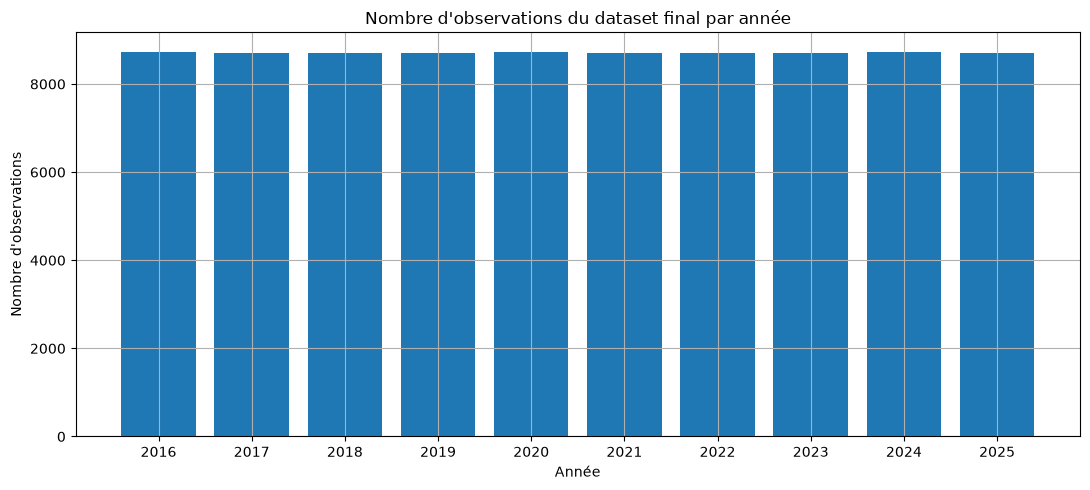

In [57]:
par_annee = (
    df.assign(annee=df["jour_cible"].dt.year)
      .groupby(["annee", "periode"])
      .size()
      .rename("nb_observations")
      .reset_index()
)

display(par_annee)

fig, ax = plt.subplots(figsize=(11, 5))
tmp = par_annee.groupby("annee")["nb_observations"].sum()
ax.bar(tmp.index.astype(str), tmp.values)
ax.set(
    title="Nombre d'observations du dataset final par année",
    xlabel="Année",
    ylabel="Nombre d'observations",
)
plt.tight_layout()
plt.show()

In [31]:
# Vérifications attendues du dataset final.
attendus = {
    "apprentissage": 61032,
    "validation": 8712,
    "test": 17448,
}

for periode, n in attendus.items():
    obtenu = int((df["periode"] == periode).sum())
    print(f"{periode:15s} : {obtenu:6d} | attendu : {n:6d} | OK = {obtenu == n}")

print("\nNombre d'heures cibles :", df["heure_cible"].nunique())
print("Heures :", sorted(df["heure_cible"].unique().tolist()))

apprentissage   :  61032 | attendu :  61032 | OK = True
validation      :   8712 | attendu :   8712 | OK = True
test            :  17448 | attendu :  17448 | OK = True

Nombre d'heures cibles : 24
Heures : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


## 2. Résultats gelés des quatre modèles

Les valeurs de synthèse ci-dessous correspondent aux résultats obtenus pendant les étapes de validation et de test final.

Elles permettent d'avoir un tableau unique même si les fichiers de prédictions de certains modèles ont des noms différents dans le dépôt.

In [32]:
validation_2023 = pd.DataFrame([
    {"modele":"M1", "MAE_MW":1547.951891, "RMSE_MW":2151.110442},
    {"modele":"M2", "MAE_MW":1503.534960, "RMSE_MW":2052.891423},
    {"modele":"M3", "MAE_MW":1579.716318, "RMSE_MW":2251.868368},
    {"modele":"M4", "MAE_MW":1506.412607, "RMSE_MW":2122.519217},
])

display(validation_2023.sort_values("MAE_MW"))

,modele,MAE_MW,RMSE_MW
1,M2,1503.534960,2052.891423
3,M4,1506.412607,2122.519217
0,M1,1547.951891,2151.110442
2,M3,1579.716318,2251.868368


In [33]:
test_final = pd.DataFrame([
    {
        "modele":"M1", "periode":"2024",
        "MAE_MW":1583.990, "RMSE_MW":2347.354,
        "MAE_total_journalier_MWh":33454.810,
        "MAE_pointe_MW":1769.677, "MAE_heure_pointe_h":1.868,
    },
    {
        "modele":"M1", "periode":"2025",
        "MAE_MW":1588.785, "RMSE_MW":2245.930,
        "MAE_total_journalier_MWh":34379.115,
        "MAE_pointe_MW":1686.883, "MAE_heure_pointe_h":1.837,
    },
    {
        "modele":"M1", "periode":"2024-2025",
        "MAE_MW":1586.384133, "RMSE_MW":2297.271226,
        "MAE_total_journalier_MWh":33916.326761,
        "MAE_pointe_MW":1728.336962, "MAE_heure_pointe_h":1.852820,
    },

    {
        "modele":"M2", "periode":"2024",
        "MAE_MW":1359.250, "RMSE_MW":1910.041,
        "MAE_total_journalier_MWh":29218.369,
        "MAE_pointe_MW":1521.976, "MAE_heure_pointe_h":1.940,
    },
    {
        "modele":"M2", "periode":"2025",
        "MAE_MW":1307.387, "RMSE_MW":1811.246,
        "MAE_total_journalier_MWh":27727.869,
        "MAE_pointe_MW":1381.798, "MAE_heure_pointe_h":1.683,
    },
    {
        "modele":"M2", "periode":"2024-2025",
        "MAE_MW":1333.354164, "RMSE_MW":1861.367098,
        "MAE_total_journalier_MWh":28474.144286,
        "MAE_pointe_MW":1451.983527, "MAE_heure_pointe_h":1.811554,
    },

    {
        "modele":"M3", "periode":"2024",
        "MAE_MW":1373.496770, "RMSE_MW":2025.924619,
        "MAE_total_journalier_MWh":28077.690372,
        "MAE_pointe_MW":1601.964359, "MAE_heure_pointe_h":2.269231,
    },
    {
        "modele":"M3", "periode":"2025",
        "MAE_MW":1328.465079, "RMSE_MW":1876.304971,
        "MAE_total_journalier_MWh":26920.938603,
        "MAE_pointe_MW":1430.166488, "MAE_heure_pointe_h":2.005510,
    },
    {
        "modele":"M3", "periode":"2024-2025",
        "MAE_MW":1351.011895, "RMSE_MW":1952.651275,
        "MAE_total_journalier_MWh":27500.110053,
        "MAE_pointe_MW":1516.183579, "MAE_heure_pointe_h":2.137552,
    },

    {
        "modele":"M4", "periode":"2024",
        "MAE_MW":1584.417236, "RMSE_MW":2360.796831,
        "MAE_total_journalier_MWh":33007.349863,
        "MAE_pointe_MW":1684.785737, "MAE_heure_pointe_h":2.293956,
    },
    {
        "modele":"M4", "periode":"2025",
        "MAE_MW":1568.139167, "RMSE_MW":2232.130540,
        "MAE_total_journalier_MWh":33521.204238,
        "MAE_pointe_MW":1603.935870, "MAE_heure_pointe_h":1.741047,
    },
    {
        "modele":"M4", "periode":"2024-2025",
        "MAE_MW":1576.289397, "RMSE_MW":2297.453078,
        "MAE_total_journalier_MWh":33263.923644,
        "MAE_pointe_MW":1644.416409, "MAE_heure_pointe_h":2.017882,
    },
])

display(test_final)

,modele,periode,MAE_MW,RMSE_MW,MAE_total_journalier_MWh,MAE_pointe_MW,MAE_heure_pointe_h
0,M1,2024,1583.990000,2347.354000,33454.810000,1769.677000,1.868000
1,M1,2025,1588.785000,2245.930000,34379.115000,1686.883000,1.837000
2,M1,2024-2025,1586.384133,2297.271226,33916.326761,1728.336962,1.852820
3,M2,2024,1359.250000,1910.041000,29218.369000,1521.976000,1.940000
4,M2,2025,1307.387000,1811.246000,27727.869000,1381.798000,1.683000
5,M2,2024-2025,1333.354164,1861.367098,28474.144286,1451.983527,1.811554
6,M3,2024,1373.496770,2025.924619,28077.690372,1601.964359,2.269231
7,M3,2025,1328.465079,1876.304971,26920.938603,1430.166488,2.005510
8,M3,2024-2025,1351.011895,1952.651275,27500.110053,1516.183579,2.137552
9,M4,2024,1584.417236,2360.796831,33007.349863,1684.785737,2.293956


## 3. Comparaison globale sur la validation 2023

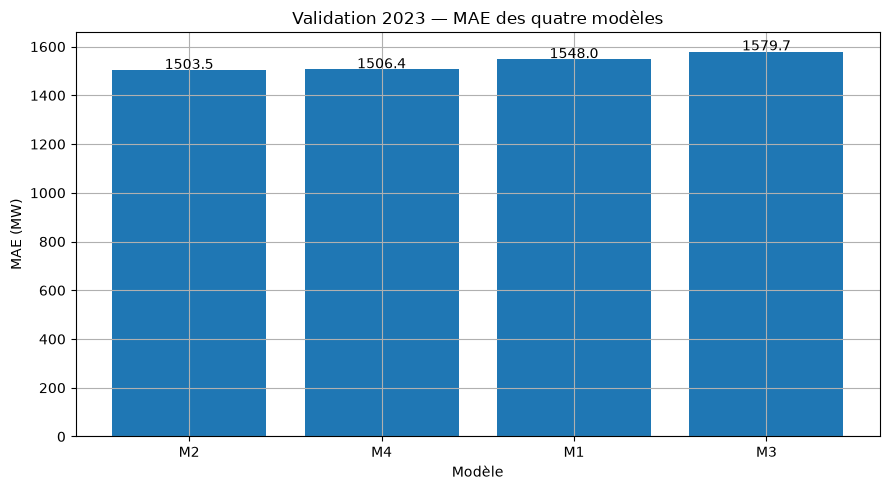

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
tmp = validation_2023.sort_values("MAE_MW")
ax.bar(tmp["modele"], tmp["MAE_MW"])
ax.set(title="Validation 2023 — MAE des quatre modèles", xlabel="Modèle", ylabel="MAE (MW)")
for i, v in enumerate(tmp["MAE_MW"]):
    ax.text(i, v + 5, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

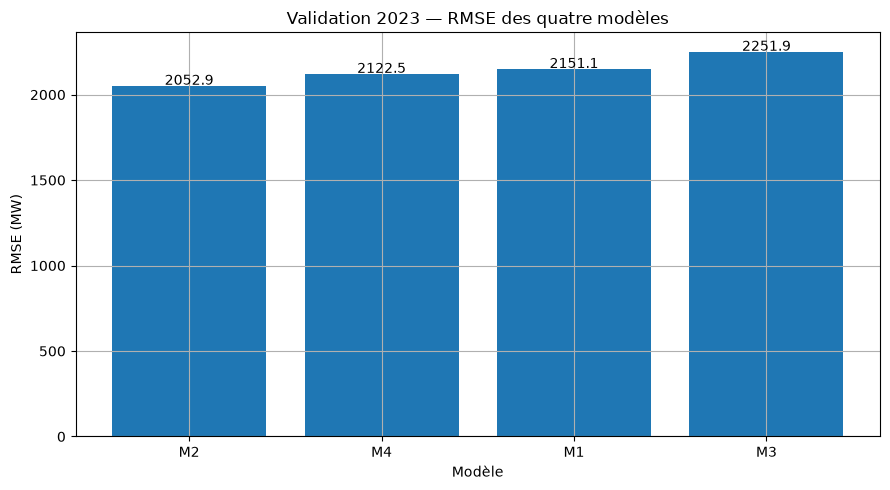

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
tmp = validation_2023.sort_values("RMSE_MW")
ax.bar(tmp["modele"], tmp["RMSE_MW"])
ax.set(title="Validation 2023 — RMSE des quatre modèles", xlabel="Modèle", ylabel="RMSE (MW)")
for i, v in enumerate(tmp["RMSE_MW"]):
    ax.text(i, v + 5, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

## 4. Comparaison finale 2024–2025

In [36]:
global_test = (
    test_final.loc[test_final["periode"] == "2024-2025"]
    .sort_values("MAE_MW")
    .reset_index(drop=True)
)

display(global_test)

,modele,periode,MAE_MW,RMSE_MW,MAE_total_journalier_MWh,MAE_pointe_MW,MAE_heure_pointe_h
0,M2,2024-2025,1333.354164,1861.367098,28474.144286,1451.983527,1.811554
1,M3,2024-2025,1351.011895,1952.651275,27500.110053,1516.183579,2.137552
2,M4,2024-2025,1576.289397,2297.453078,33263.923644,1644.416409,2.017882
3,M1,2024-2025,1586.384133,2297.271226,33916.326761,1728.336962,1.852820


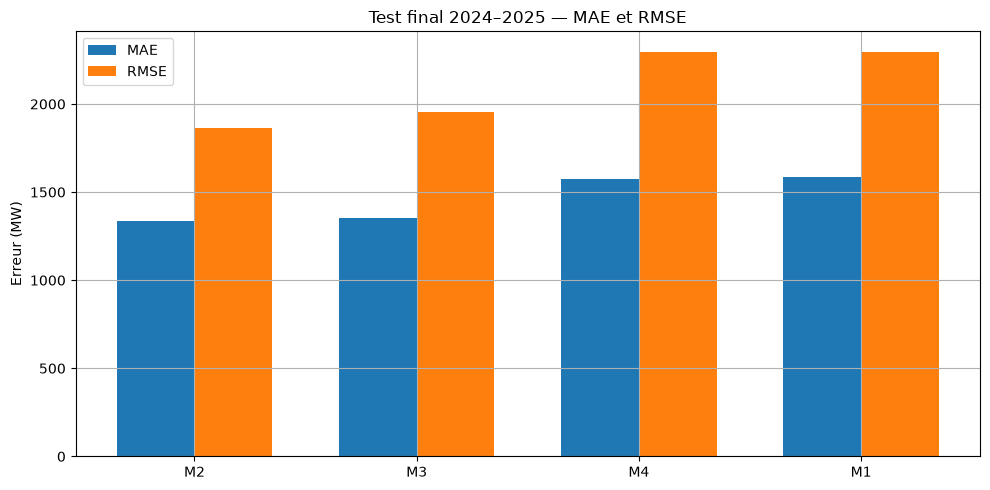

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(global_test))
w = 0.35

ax.bar(x - w/2, global_test["MAE_MW"], w, label="MAE")
ax.bar(x + w/2, global_test["RMSE_MW"], w, label="RMSE")

ax.set_xticks(x, global_test["modele"])
ax.set_ylabel("Erreur (MW)")
ax.set_title("Test final 2024–2025 — MAE et RMSE")
ax.legend()

plt.tight_layout()
plt.show()

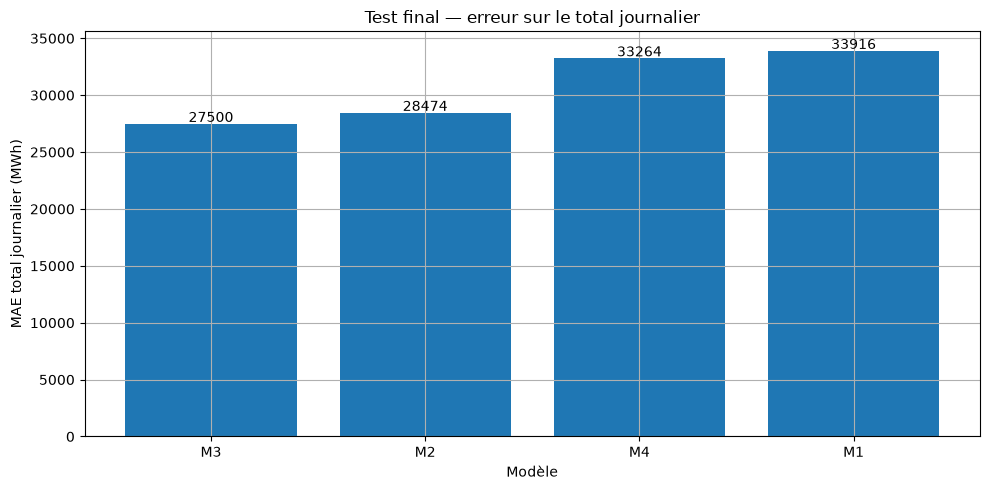

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
tmp = global_test.sort_values("MAE_total_journalier_MWh")
ax.bar(tmp["modele"], tmp["MAE_total_journalier_MWh"])
ax.set(
    title="Test final — erreur sur le total journalier",
    xlabel="Modèle",
    ylabel="MAE total journalier (MWh)",
)
for i, v in enumerate(tmp["MAE_total_journalier_MWh"]):
    ax.text(i, v + 150, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.show()

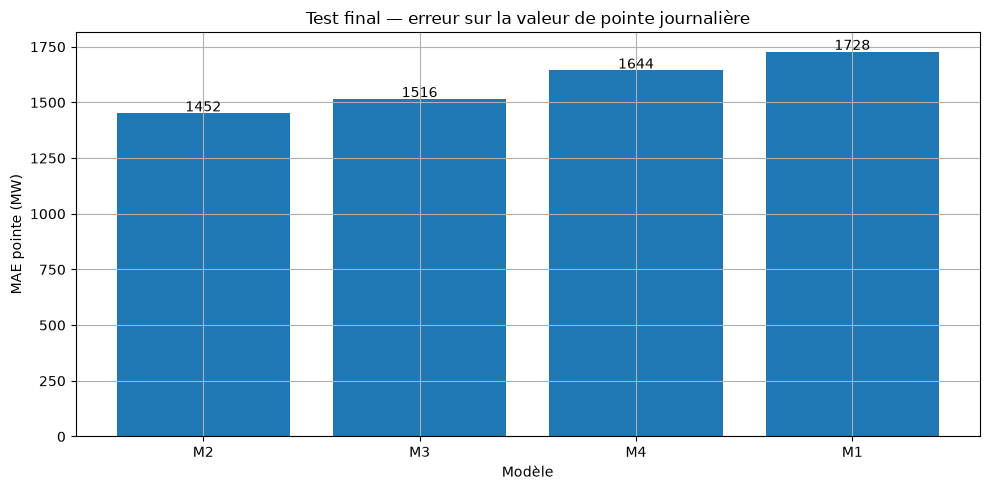

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
tmp = global_test.sort_values("MAE_pointe_MW")
ax.bar(tmp["modele"], tmp["MAE_pointe_MW"])
ax.set(
    title="Test final — erreur sur la valeur de pointe journalière",
    xlabel="Modèle",
    ylabel="MAE pointe (MW)",
)
for i, v in enumerate(tmp["MAE_pointe_MW"]):
    ax.text(i, v + 8, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.show()

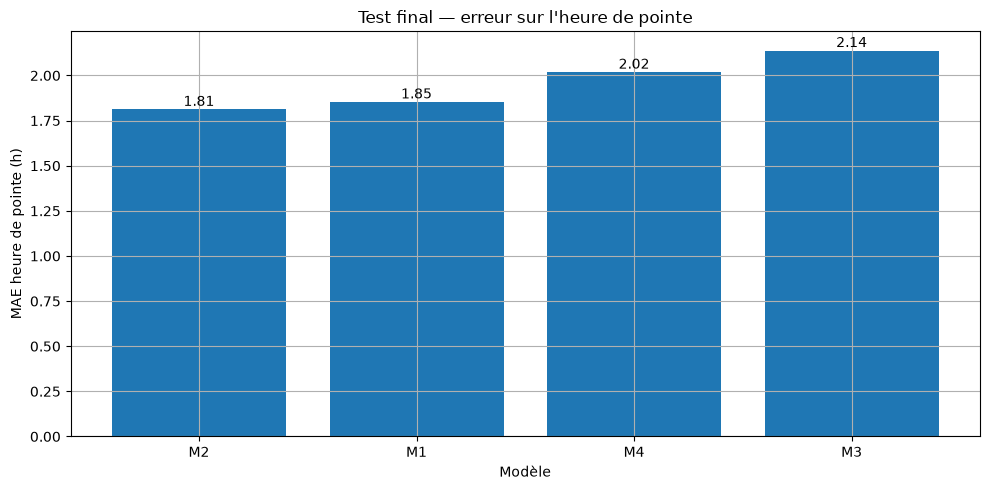

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
tmp = global_test.sort_values("MAE_heure_pointe_h")
ax.bar(tmp["modele"], tmp["MAE_heure_pointe_h"])
ax.set(
    title="Test final — erreur sur l'heure de pointe",
    xlabel="Modèle",
    ylabel="MAE heure de pointe (h)",
)
for i, v in enumerate(tmp["MAE_heure_pointe_h"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## 5. Robustesse : résultats séparés en 2024 et 2025

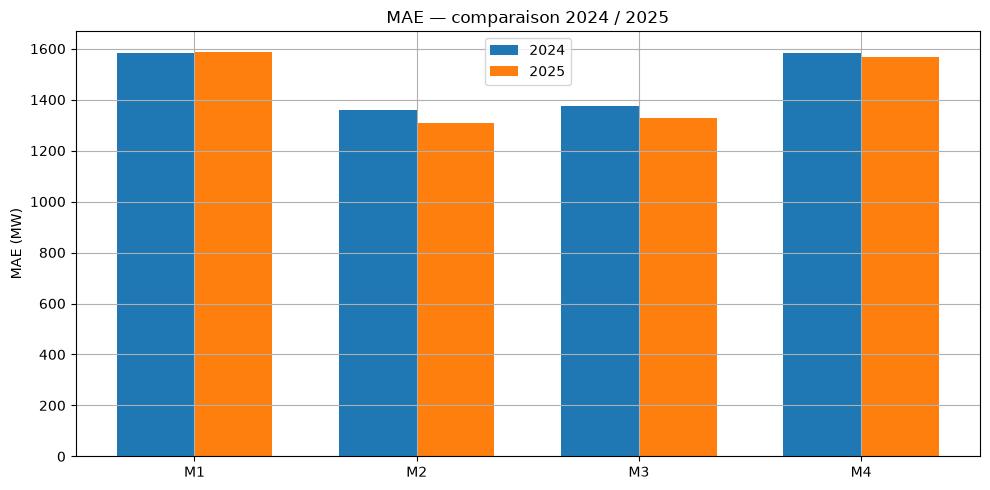

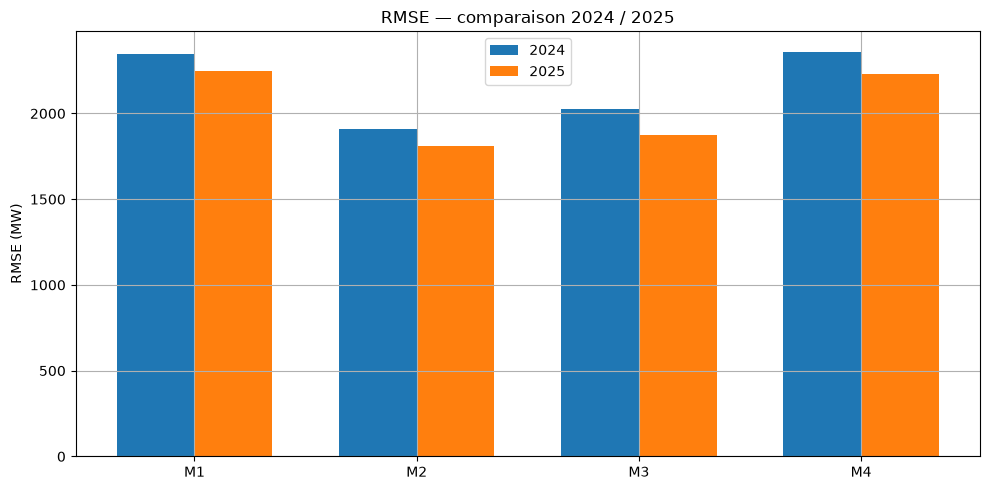

In [41]:
for metrique, ylabel in [
    ("MAE_MW", "MAE (MW)"),
    ("RMSE_MW", "RMSE (MW)"),
]:
    tmp = test_final[test_final["periode"].isin(["2024", "2025"])].copy()
    pivot = tmp.pivot(index="modele", columns="periode", values=metrique).loc[["M1","M2","M3","M4"]]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(pivot))
    w = 0.35

    ax.bar(x - w/2, pivot["2024"], w, label="2024")
    ax.bar(x + w/2, pivot["2025"], w, label="2025")

    ax.set_xticks(x, pivot.index)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metrique.replace('_MW','')} — comparaison 2024 / 2025")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 6. Gains relatifs par rapport à M1

In [42]:
base = global_test.set_index("modele").loc["M1"]

gains = global_test.copy()
for metrique in ["MAE_MW", "RMSE_MW", "MAE_total_journalier_MWh", "MAE_pointe_MW"]:
    gains[f"gain_{metrique}_pct"] = 100 * (base[metrique] - gains[metrique]) / base[metrique]

display(gains[[
    "modele",
    "gain_MAE_MW_pct",
    "gain_RMSE_MW_pct",
    "gain_MAE_total_journalier_MWh_pct",
    "gain_MAE_pointe_MW_pct",
]])

,modele,gain_MAE_MW_pct,gain_RMSE_MW_pct,gain_MAE_total_journalier_MWh_pct,gain_MAE_pointe_MW_pct
0,M2,15.950107,18.974866,16.045908,15.989558
1,M3,14.837027,15.001274,18.917782,12.275001
2,M4,0.636336,-0.007916,1.923567,4.855567
3,M1,0.000000,0.000000,0.000000,0.000000


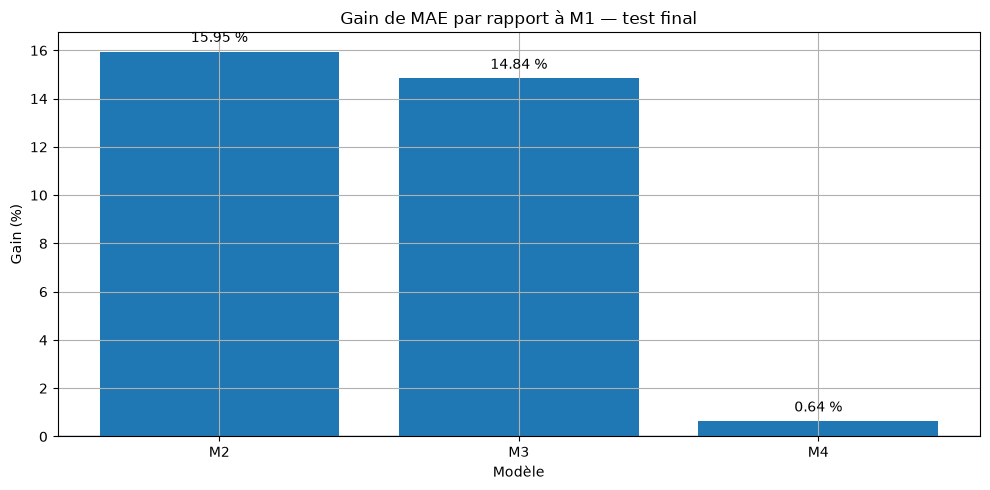

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
tmp = gains.set_index("modele").loc[["M2","M3","M4"]]
ax.bar(tmp.index, tmp["gain_MAE_MW_pct"])
ax.axhline(0, linewidth=1)
ax.set(
    title="Gain de MAE par rapport à M1 — test final",
    xlabel="Modèle",
    ylabel="Gain (%)",
)
for i, v in enumerate(tmp["gain_MAE_MW_pct"]):
    ax.text(i, v + (0.4 if v >= 0 else -0.8), f"{v:.2f} %", ha="center")
plt.tight_layout()
plt.show()

## 7. Recherche automatique des fichiers de prédictions finales

Cette partie cherche les fichiers déjà présents dans `data/resultats`. Elle ne crée aucune nouvelle prédiction.

Le but est d'utiliser les **vraies prédictions enregistrées** pour les analyses par heure, par jour et les courbes réel/prédit.

In [44]:
fichiers = sorted(RESULTATS.glob("*.csv"))
print("Fichiers CSV disponibles dans data/resultats :")
for f in fichiers:
    print(" -", f.name)

Fichiers CSV disponibles dans data/resultats :
 - ablation_calendrier_m1_2023.csv
 - ablation_calendrier_m1_2023_par_trimestre.csv
 - ablation_lags_m1_2023.csv
 - ablation_lags_m1_2023_par_groupe_heures.csv
 - ablation_lags_m1_2023_par_trimestre.csv
 - ablation_m2_2023.csv
 - ablation_m2_2023_par_heure.csv
 - ablation_m2_2023_par_trimestre.csv
 - ablation_retards_m1_2023.csv
 - ablation_retards_m1_2023_par_trimestre.csv
 - predictions_test_final_m1_2024_2025.csv
 - predictions_test_final_m2_2024_2025.csv
 - predictions_test_final_m3_2024_2025.csv
 - predictions_test_final_m4_2024_2025.csv
 - selection_m3_validation_2023.csv
 - selection_m4_validation_2023.csv
 - test_final_m1_m2_2024_2025.csv
 - test_final_m3_2024_2025.csv
 - test_final_m4_2024_2025.csv


In [45]:
def trouver_prediction(modele):
    modele = modele.lower()
    candidats = [
        f for f in RESULTATS.glob("*.csv")
        if "prediction" in f.name.lower()
        and modele in f.name.lower()
        and ("2024" in f.name or "test_final" in f.name.lower())
    ]
    if not candidats:
        return None
    candidats = sorted(candidats, key=lambda p: ("2024_2025" not in p.name, len(p.name)))
    return candidats[0]

fichiers_predictions = {m: trouver_prediction(m) for m in ["m1","m2","m3","m4"]}

for modele, fichier in fichiers_predictions.items():
    print(modele.upper(), ":", fichier.name if fichier else "NON TROUVÉ")

M1 : predictions_test_final_m1_2024_2025.csv
M2 : predictions_test_final_m2_2024_2025.csv
M3 : predictions_test_final_m3_2024_2025.csv
M4 : predictions_test_final_m4_2024_2025.csv


In [46]:
predictions = {}

for modele, fichier in fichiers_predictions.items():
    if fichier is None:
        continue

    p = pd.read_csv(fichier)

    if "jour_cible" in p.columns:
        p["jour_cible"] = pd.to_datetime(p["jour_cible"])

    predictions[modele.upper()] = p

    print(
        modele.upper(),
        "->",
        p.shape,
        "|",
        p["jour_cible"].min() if "jour_cible" in p else "?",
        "à",
        p["jour_cible"].max() if "jour_cible" in p else "?",
    )
    print("   colonnes :", p.columns.tolist())

M1 -> (17448, 5) | 2024-01-01 00:00:00 à 2025-12-31 00:00:00
   colonnes : ['jour_cible', 'heure_cible', 'consommation_cible_MW', 'prediction_MW', 'bloc_test']
M2 -> (17448, 5) | 2024-01-01 00:00:00 à 2025-12-31 00:00:00
   colonnes : ['jour_cible', 'heure_cible', 'consommation_cible_MW', 'prediction_MW', 'bloc_test']
M3 -> (17448, 48) | 2024-01-01 00:00:00 à 2025-12-31 00:00:00
   colonnes : ['jour_origine', 'date_heure_origine_utc', 'jour_cible', 'heure_cible', 'date_heure_cible_utc', 'horizon_h', 'periode', 'exclu_covid', 'conso_veille_effective_MW', 'retard_effectif_h', 'conso_lag48_MW', 'conso_lag168_MW', 'jour_semaine', 'mois', 'weekend', 'ferie', 'veille_ferie', 'lendemain_ferie', 'pont_potentiel', 'vacances_A', 'vacances_B', 'vacances_C', 'nb_zones_vacances', 'periode_noel', 'temp_8_villes_origine', 'temp_8_villes_veille', 'temp_8_villes_lissee', 'temp_8_villes_degres_chauffage_origine', 'temp_8_villes_degres_chauffage_lisses', 'temp_8_villes_degres_climatisation_origine', 'tem

## 8. Harmonisation des prédictions

Les fichiers peuvent avoir des noms de colonnes légèrement différents. La cellule suivante détecte automatiquement la cible et la prédiction principale.

In [47]:
def trouver_colonne_prediction(table, modele):
    candidats_specifiques = [
        f"prediction_{modele}_MW",
        f"prediction_{modele.lower()}_MW",
    ]
    if modele == "M4":
        candidats_specifiques = ["prediction_MW"] + candidats_specifiques

    for c in candidats_specifiques:
        if c in table.columns:
            return c

    candidats = [
        c for c in table.columns
        if "prediction" in c.lower()
        and "m1" not in c.lower()
        and "correction" not in c.lower()
    ]

    if len(candidats) == 1:
        return candidats[0]

    if "prediction_MW" in table.columns:
        return "prediction_MW"

    return None


pred_long = []

for modele, p in predictions.items():
    col_pred = trouver_colonne_prediction(p, modele)

    if col_pred is None:
        print(f"{modele}: colonne de prédiction non identifiée -> ignoré pour les graphes détaillés.")
        continue

    colonnes = ["jour_cible", "heure_cible", "consommation_cible_MW", col_pred]

    if not all(c in p.columns for c in colonnes):
        print(f"{modele}: colonnes nécessaires absentes -> ignoré.")
        continue

    q = p[colonnes].copy()
    q = q.rename(columns={col_pred: "prediction_MW"})
    q["modele"] = modele
    q["erreur_MW"] = q["consommation_cible_MW"] - q["prediction_MW"]
    q["erreur_abs_MW"] = q["erreur_MW"].abs()

    pred_long.append(q)

if pred_long:
    pred_long = pd.concat(pred_long, ignore_index=True)
    print("Modèles disponibles pour analyse détaillée :", sorted(pred_long["modele"].unique()))
    print("Dimensions :", pred_long.shape)
else:
    pred_long = pd.DataFrame()
    print("Aucun fichier de prédictions harmonisable.")

Modèles disponibles pour analyse détaillée : ['M1', 'M2', 'M3', 'M4']
Dimensions : (69792, 7)


## 9. MAE par heure cible

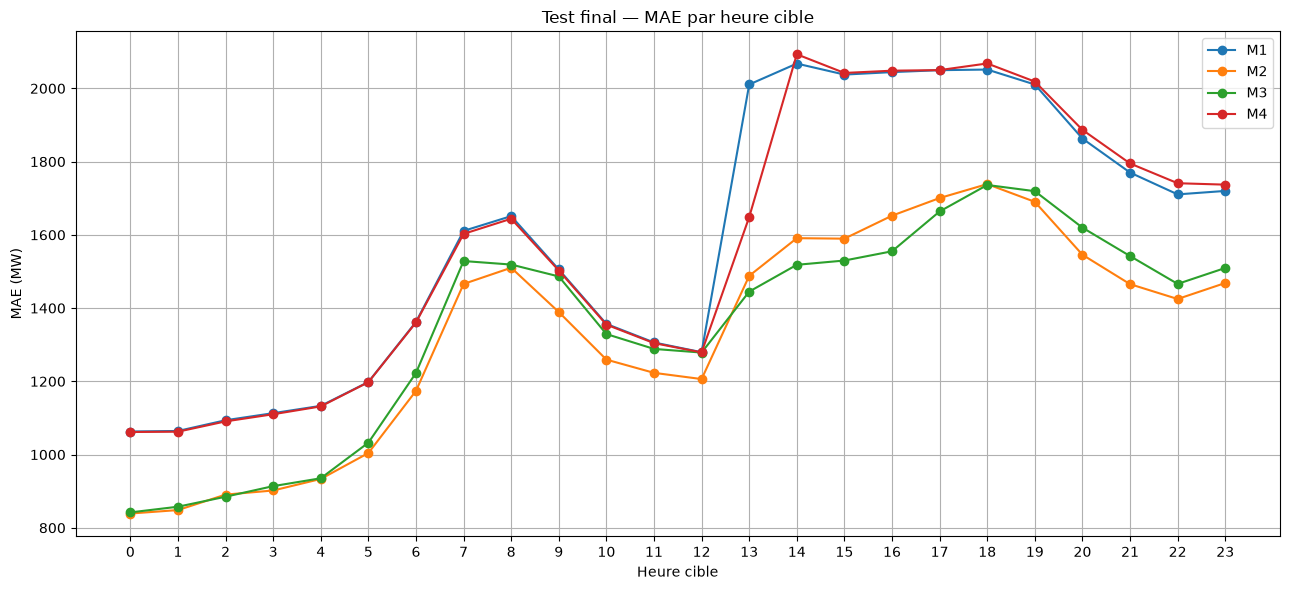

modele,M1,M2,M3,M4
heure_cible,,,,
0,1062.997362,839.008871,842.121467,1061.632190
1,1064.486953,848.494825,857.612938,1062.506615
2,1093.784791,890.679776,884.945936,1090.624371
3,1113.091453,901.934850,913.826197,1110.145209
4,1133.050599,933.418244,935.299094,1131.568212
5,1198.133985,1004.230384,1032.467513,1197.745039
6,1362.202282,1173.956497,1222.862690,1360.761935
7,1610.801317,1465.938743,1528.516504,1602.668447
8,1651.170811,1510.144459,1518.889401,1644.019754


In [48]:
if not pred_long.empty:
    par_heure = (
        pred_long.groupby(["modele", "heure_cible"])["erreur_abs_MW"]
        .mean()
        .reset_index(name="MAE_MW")
    )

    fig, ax = plt.subplots(figsize=(13, 6))

    for modele, g in par_heure.groupby("modele"):
        ax.plot(g["heure_cible"], g["MAE_MW"], marker="o", label=modele)

    ax.set_xticks(range(24))
    ax.set(
        title="Test final — MAE par heure cible",
        xlabel="Heure cible",
        ylabel="MAE (MW)",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(par_heure.pivot(index="heure_cible", columns="modele", values="MAE_MW"))
else:
    print("Analyse non disponible : fichiers de prédictions manquants.")

## 10. Biais moyen par heure cible

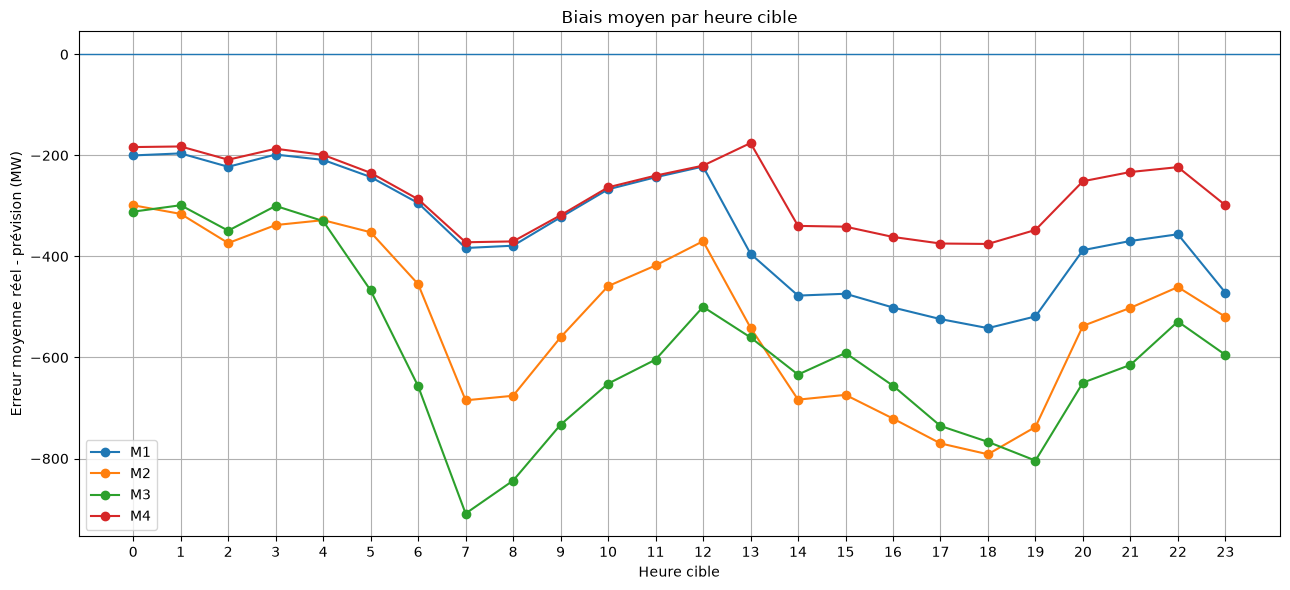

In [49]:
if not pred_long.empty:
    biais = (
        pred_long.groupby(["modele", "heure_cible"])["erreur_MW"]
        .mean()
        .reset_index(name="biais_MW")
    )

    fig, ax = plt.subplots(figsize=(13, 6))

    for modele, g in biais.groupby("modele"):
        ax.plot(g["heure_cible"], g["biais_MW"], marker="o", label=modele)

    ax.axhline(0, linewidth=1)
    ax.set_xticks(range(24))
    ax.set(
        title="Biais moyen par heure cible",
        xlabel="Heure cible",
        ylabel="Erreur moyenne réel - prévision (MW)",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Analyse non disponible.")

## 11. Distribution des erreurs

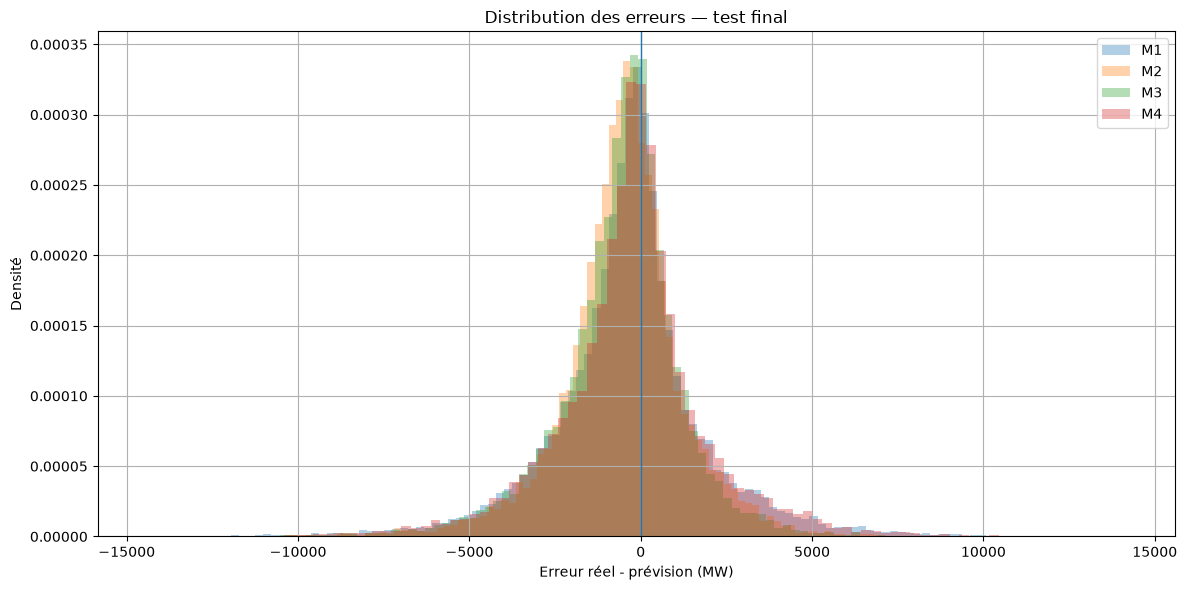

,mean,std,median,min,max
modele,,,,,
M1,-349.919653,2270.530068,-280.270508,-11960.189320,11489.895409
M2,-523.607640,1786.254569,-455.996799,-11799.752034,9105.561331
M3,-587.119604,1862.347001,-403.357130,-13751.011571,11107.481758
M4,-274.499921,2281.060861,-200.707593,-14419.980021,14155.378775


In [50]:
if not pred_long.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    for modele, g in pred_long.groupby("modele"):
        ax.hist(
            g["erreur_MW"],
            bins=100,
            alpha=0.35,
            label=modele,
            density=True,
        )

    ax.axvline(0, linewidth=1)
    ax.set(
        title="Distribution des erreurs — test final",
        xlabel="Erreur réel - prévision (MW)",
        ylabel="Densité",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    resume = pred_long.groupby("modele")["erreur_MW"].agg(
        ["mean", "std", "median", "min", "max"]
    )
    display(resume)
else:
    print("Analyse non disponible.")

## 12. Évolution de la MAE journalière

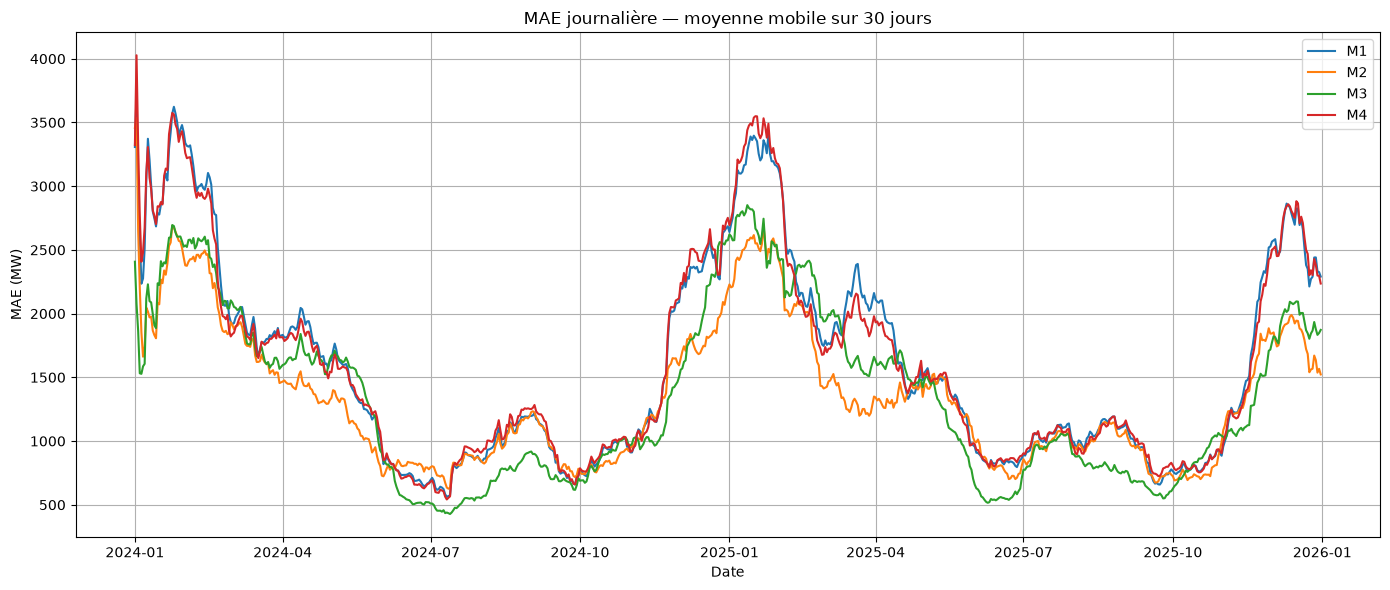

In [51]:
if not pred_long.empty:
    journalier = (
        pred_long.groupby(["modele", "jour_cible"])["erreur_abs_MW"]
        .mean()
        .reset_index(name="MAE_journaliere_MW")
    )

    fig, ax = plt.subplots(figsize=(14, 6))

    for modele, g in journalier.groupby("modele"):
        g = g.sort_values("jour_cible").copy()
        g["MAE_30j"] = g["MAE_journaliere_MW"].rolling(30, min_periods=1).mean()
        ax.plot(g["jour_cible"], g["MAE_30j"], label=modele)

    ax.set(
        title="MAE journalière — moyenne mobile sur 30 jours",
        xlabel="Date",
        ylabel="MAE (MW)",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Analyse non disponible.")

## 13. Courbe réel / prédit sur une semaine

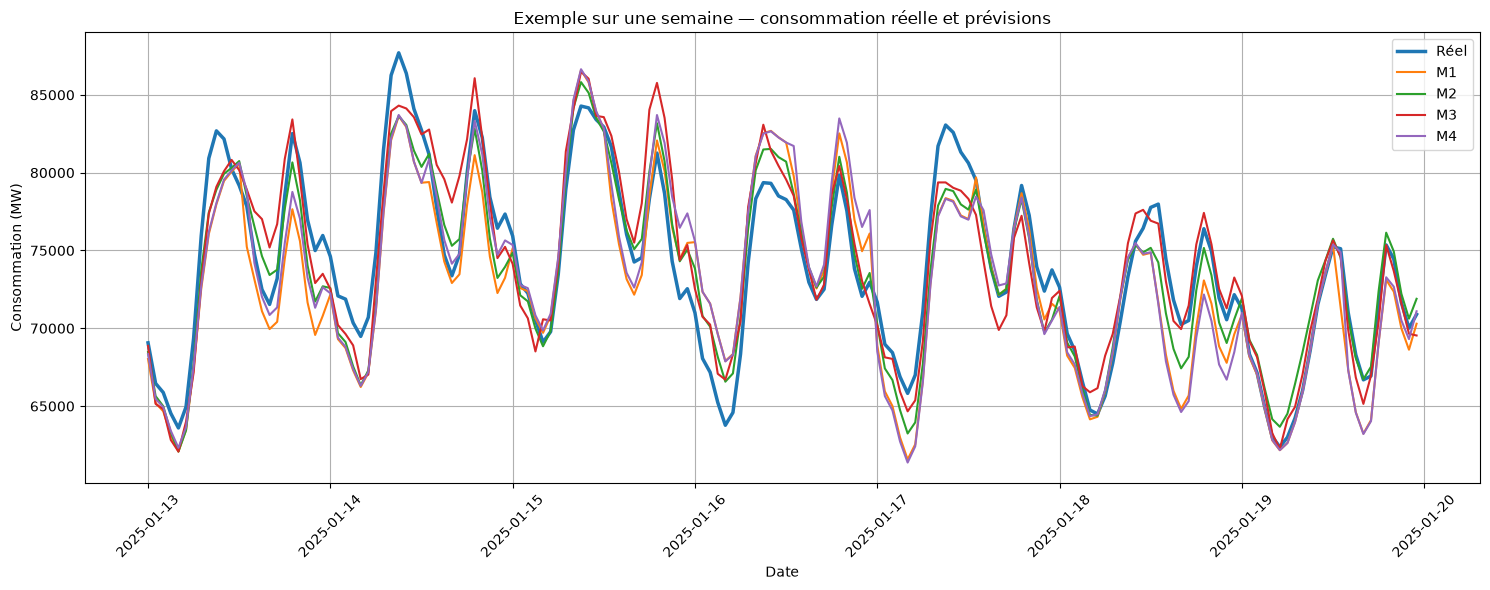

In [52]:
if not pred_long.empty:
    debut = pd.Timestamp("2025-01-13")
    fin = debut + pd.Timedelta(days=7)

    exemple = pred_long.loc[
        (pred_long["jour_cible"] >= debut)
        & (pred_long["jour_cible"] < fin)
    ].copy()

    exemple["instant"] = (
        exemple["jour_cible"]
        + pd.to_timedelta(exemple["heure_cible"], unit="h")
    )

    reel = (
        exemple[["instant", "consommation_cible_MW"]]
        .drop_duplicates("instant")
        .sort_values("instant")
    )

    fig, ax = plt.subplots(figsize=(15, 6))

    ax.plot(
        reel["instant"],
        reel["consommation_cible_MW"],
        linewidth=2.5,
        label="Réel",
    )

    for modele, g in exemple.groupby("modele"):
        g = g.sort_values("instant")
        ax.plot(g["instant"], g["prediction_MW"], label=modele)

    ax.set(
        title="Exemple sur une semaine — consommation réelle et prévisions",
        xlabel="Date",
        ylabel="Consommation (MW)",
    )
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Analyse non disponible.")

## 14. Quel modèle gagne le plus souvent ?

,nb_observations,part_pct
M3,6121,35.081385
M2,5034,28.851444
M4,3331,19.091013
M1,2962,16.976158


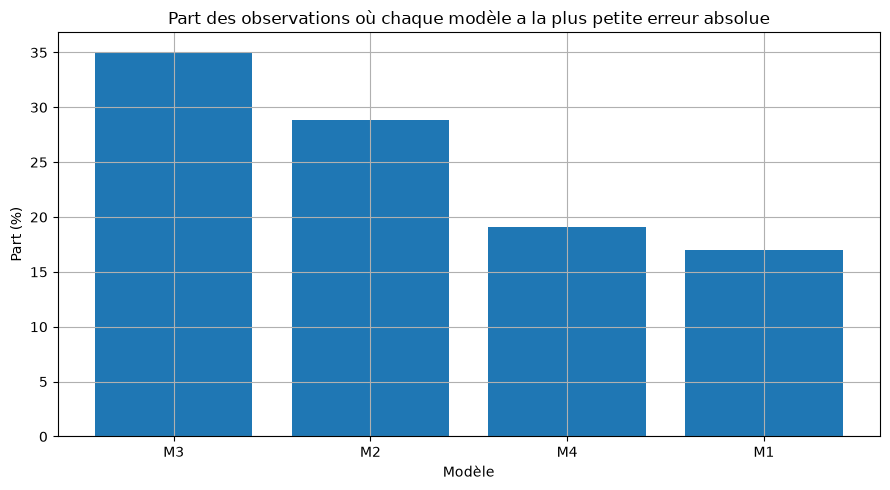

In [53]:
if not pred_long.empty:
    pivot = pred_long.pivot_table(
        index=["jour_cible", "heure_cible"],
        columns="modele",
        values="erreur_abs_MW",
        aggfunc="first",
    ).dropna()

    if not pivot.empty:
        gagnant_obs = pivot.idxmin(axis=1)
        victoires = gagnant_obs.value_counts().rename("nb_observations").to_frame()
        victoires["part_pct"] = 100 * victoires["nb_observations"] / len(pivot)

        display(victoires)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(victoires.index, victoires["part_pct"])
        ax.set(
            title="Part des observations où chaque modèle a la plus petite erreur absolue",
            xlabel="Modèle",
            ylabel="Part (%)",
        )
        plt.tight_layout()
        plt.show()
    else:
        print("Pas assez de prédictions communes.")
else:
    print("Analyse non disponible.")

## 15. Classements selon les différentes métriques

In [54]:
metriques_classement = [
    "MAE_MW",
    "RMSE_MW",
    "MAE_total_journalier_MWh",
    "MAE_pointe_MW",
    "MAE_heure_pointe_h",
]

classements = []

for metrique in metriques_classement:
    tmp = global_test[["modele", metrique]].sort_values(metrique).reset_index(drop=True)
    tmp["rang"] = np.arange(1, len(tmp) + 1)
    tmp["metrique"] = metrique
    tmp = tmp.rename(columns={metrique: "valeur"})
    classements.append(tmp)

classements = pd.concat(classements, ignore_index=True)
display(classements.pivot(index="modele", columns="metrique", values="rang"))

metrique,MAE_MW,MAE_heure_pointe_h,MAE_pointe_MW,MAE_total_journalier_MWh,RMSE_MW
modele,,,,,
M1,4,2,4,4,3
M2,1,1,1,2,1
M3,2,4,2,1,2
M4,3,3,3,3,4


## 16. Synthèse scientifique

### Validation 2023

Selon la MAE :

1. **M2** : 1503.535 MW ;
2. **M4** : 1506.413 MW ;
3. **M1** : 1547.952 MW ;
4. **M3** : 1579.716 MW.

### Test final 2024–2025

Selon la MAE globale :

1. **M2** : 1333.354 MW ;
2. **M3** : 1351.012 MW ;
3. **M4** : 1576.289 MW ;
4. **M1** : 1586.384 MW.

Selon le RMSE global :

1. **M2** : 1861.367 MW ;
2. **M3** : 1952.651 MW ;
3. **M1** : 2297.271 MW ;
4. **M4** : 2297.453 MW.

### Interprétation provisoire

- **M2 est le meilleur modèle principal** sur les critères MAE et RMSE du test final.
- L'ajout de la météo à M1 apporte un gain important et stable en 2024 comme en 2025.
- M3 exploite des non-linéarités et obtient de très bonnes performances, mais reste derrière M2 sur MAE/RMSE.
- M3 obtient néanmoins la meilleure erreur sur le **total journalier**, ce qui doit être signalé.
- M4 améliore légèrement la MAE de M1 mais son gain hors échantillon est faible ; son RMSE global est pratiquement identique à celui de M1.

L'interprétation définitive doit être complétée après inspection des graphes détaillés produits par ce notebook.

## 17. Contrôles avant conclusion définitive

Après `Run All`, vérifier :

- que les dimensions du dataset sont celles attendues ;
- que les quatre fichiers de prédictions sont correctement détectés ;
- que les métriques recalculées à partir des prédictions correspondent aux résultats enregistrés ;
- que les courbes par heure ne révèlent pas d'anomalie ;
- que les erreurs extrêmes sont interprétables ;
- que la comparaison 2024/2025 confirme la stabilité des conclusions.

**Important :** ce notebook est analytique. Aucun résultat observé ici ne doit conduire à retuner les modèles sur 2024–2025.

# 18. Analyse et interprétation des résultats

Cette section rassemble l'interprétation scientifique des résultats obtenus dans les cellules précédentes. Elle ne modifie aucun modèle et n'effectue aucune nouvelle sélection.

## 18.1. Validation du dataset final

Les contrôles effectués sur le dataset final confirment sa cohérence pour la modélisation :

- **87 192 observations** et **46 variables** ;
- période couverte : **2016–2025** ;
- **61 032 observations d'apprentissage**, **8 712 de validation** et **17 448 de test** ;
- **aucune valeur manquante** ;
- **aucun doublon jour/heure** ;
- les **24 heures cibles** sont représentées.

La séparation chronologique est donc conforme au protocole retenu. Les résultats des modèles peuvent être comparés sur une base commune.

## 18.2. Résultat principal : M2 est le meilleur modèle global

Sur le test final 2024–2025, les performances globales sont :

| Modèle | MAE (MW) | RMSE (MW) |
|---|---:|---:|
| **M2** | **1333.354** | **1861.367** |
| M3 | 1351.012 | 1952.651 |
| M4 | 1576.289 | 2297.453 |
| M1 | 1586.384 | 2297.271 |

M2 obtient simultanément la **plus faible MAE** et le **plus faible RMSE**. Par rapport à M1, il réduit la MAE d'environ **15,95 %** et le RMSE d'environ **18,98 %**.

Ce résultat montre que l'ajout de la météo disponible à l'origine de prévision apporte une information prédictive importante au-delà du calendrier et de l'inertie de consommation déjà présents dans M1.

M2 constitue donc le **modèle principal retenu** lorsque le critère prioritaire est la précision horaire globale.

## 18.3. Stabilité de M2 entre validation et test

En validation 2023, le classement selon la MAE est :

1. **M2 : 1503.535 MW** ;
2. M4 : 1506.413 MW ;
3. M1 : 1547.952 MW ;
4. M3 : 1579.716 MW.

M2 était donc déjà le meilleur modèle sur la période utilisée pour la sélection. Sur le test final 2024–2025, son avantage devient plus net.

Les résultats annuels confirment également sa stabilité :

- **2024 : MAE = 1359.250 MW** ;
- **2025 : MAE = 1307.387 MW**.

Le modèle reste performant sur les deux années du test. Son bon résultat global n'est donc pas dû à une seule année particulièrement favorable.

## 18.4. M3 : très compétitif, surtout pour certaines heures et le total journalier

M3 obtient une MAE globale de **1351.012 MW**, très proche des **1333.354 MW** de M2. Il améliore M1 d'environ **14,84 % en MAE** et **15,00 % en RMSE**.

L'analyse par heure montre que M3 devient particulièrement compétitif pendant certaines heures de forte consommation. Il dépasse notamment M2 sur plusieurs heures de l'après-midi. Cela suggère que les **non-linéarités et interactions** apprises par le HistGradientBoostingRegressor sont utiles lorsque la relation entre calendrier, météo, retards et consommation devient plus complexe.

M3 obtient par ailleurs la meilleure erreur sur le **total journalier** :

- **M3 : 27 500 MWh** ;
- M2 : 28 474 MWh ;
- M4 : 33 264 MWh ;
- M1 : 33 916 MWh.

Ainsi, M2 reste préférable pour la précision horaire globale, mais M3 est particulièrement intéressant lorsque l'objectif porte sur l'énergie totale consommée au cours d'une journée.

## 18.5. Pourquoi M2 reste devant M3 malgré de nombreuses victoires ponctuelles

L'analyse observation par observation montre que M3 possède la plus faible erreur absolue sur environ **35,08 %** des observations, contre environ **28,85 %** pour M2.

Cela ne contredit pas la meilleure MAE de M2.

M3 peut être légèrement meilleur sur un plus grand nombre de points tout en commettant, sur certaines observations, des erreurs plus importantes. Le RMSE est particulièrement sensible à ces grandes erreurs :

- **RMSE M2 : 1861.367 MW** ;
- **RMSE M3 : 1952.651 MW**.

Les distributions d'erreurs montrent également des valeurs extrêmes plus importantes pour M3. M2 présente donc un compromis plus favorable entre fréquence des bonnes prédictions et maîtrise des grandes erreurs.

C'est pourquoi M2 reste le meilleur choix selon les deux critères principaux MAE et RMSE.

## 18.6. Analyse du biais

L'erreur utilisée dans le notebook est définie par :

\[
e = Y_{\mathrm{réel}}-\widehat{Y}.
\]

Une erreur moyenne négative correspond donc à une tendance à **surestimer** la consommation.

Les erreurs moyennes observées sont approximativement :

- M1 : **−350 MW** ;
- M2 : **−524 MW** ;
- M3 : **−587 MW** ;
- M4 : **−274 MW**.

Les quatre modèles présentent donc un biais moyen de surestimation, avec une amplitude différente.

M4 possède le biais moyen le plus proche de zéro, mais il ne possède pas la meilleure MAE ni le meilleur RMSE. Cela illustre un point important : **réduire le biais moyen ne suffit pas à garantir une meilleure précision globale**, car la dispersion des erreurs doit également être prise en compte.

## 18.7. Analyse de M4 : une mémoire résiduelle existe, mais son gain est faible hors échantillon

M4 ajoute à M1 une correction ARMA destinée à exploiter la dépendance temporelle des erreurs.

En validation 2023 :

- M1 : MAE = **1547.952 MW** ;
- M4 : MAE = **1506.413 MW**.

La réduction est d'environ **2,68 %**, ce qui suggère qu'une partie des erreurs de M1 présente une persistance temporelle exploitable.

Sur le test final 2024–2025 :

- M1 : MAE = **1586.384 MW** ;
- M4 : MAE = **1576.289 MW**.

Le gain n'est plus que d'environ **0,64 %**.

Pour le RMSE :

- M1 : **2297.271 MW** ;
- M4 : **2297.453 MW**.

Les deux valeurs sont pratiquement identiques, M4 étant même très légèrement supérieur.

La conclusion est donc que la mémoire des erreurs de M1 existe, mais que son exploitation par l'ARMA(1,0) apporte **peu de gain prédictif stable hors échantillon**.

## 18.8. Effet de l'horizon sur M4

L'analyse par heure montre que le gain de M4 n'est pas uniforme.

À certaines heures proches de l'information résiduelle disponible, la correction peut être utile. En revanche, son intérêt diminue lorsque l'horizon de prévision augmente.

Ce comportement est cohérent avec un modèle ARMA : lorsque l'horizon augmente, la prévision de la composante résiduelle tend progressivement vers son niveau moyen. Si la mémoire des erreurs est courte, la correction devient alors faible et M4 se rapproche de M1.

Cela explique pourquoi M4 peut améliorer certaines heures sans produire une amélioration importante de la performance globale.

## 18.9. Le classement dépend de la métrique

Les modèles ne répondent pas exactement de la même manière à tous les objectifs.

| Critère | Meilleur modèle | Deuxième |
|---|---|---|
| MAE horaire | **M2** | M3 |
| RMSE horaire | **M2** | M3 |
| Total journalier | **M3** | M2 |
| Valeur de pointe | **M2** | M3 |
| Heure de pointe | **M2** | M1 |

M2 arrive donc premier sur **quatre des cinq critères principaux** analysés.

M3 est cependant le meilleur pour la prévision du total journalier. Cette différence rappelle que le « meilleur modèle » dépend toujours de la fonction d'évaluation considérée.

Dans ce projet, puisque MAE et RMSE constituent les critères principaux de précision horaire, **M2 est retenu comme modèle principal**.

## 18.10. Conclusion générale

Les expériences permettent de répondre progressivement aux questions associées aux quatre modèles.

### M1 — Calendrier et inertie

M1 fournit une base solide grâce au calendrier et aux retards de consommation. Sa MAE finale de **1586 MW** constitue la référence à améliorer.

### M2 — Apport de la météo

M2 apporte l'amélioration la plus importante. Avec une MAE de **1333 MW**, il réduit l'erreur d'environ **16 %** par rapport à M1. La météo disponible au moment de la prévision contient donc une information essentielle pour expliquer les variations de consommation.

### M3 — Non-linéarités et interactions

M3 atteint une MAE de **1351 MW**, très proche de M2. Les non-linéarités améliorent fortement M1 et deviennent particulièrement utiles à certaines heures. M3 obtient également le meilleur résultat sur le total journalier. Cependant, ses erreurs extrêmes plus importantes pénalisent son RMSE.

### M4 — Dynamique des erreurs

M4 montre qu'il existe une certaine persistance temporelle dans les erreurs de M1. Cette structure permet une amélioration en validation, mais son gain devient très faible sur le test final. La dynamique résiduelle seule ne suffit donc pas à concurrencer les modèles utilisant explicitement la météo.

### Choix final

**M2 est retenu comme modèle principal du projet.**

Il offre le meilleur compromis global :

- meilleure MAE ;
- meilleur RMSE ;
- meilleure erreur sur la valeur de pointe ;
- meilleure erreur sur l'heure de pointe ;
- résultats stables en 2024 et 2025.

M3 constitue néanmoins une alternative très compétitive et apporte une information complémentaire sur l'intérêt des relations non linéaires.

## 18.11. Point méthodologique à conserver dans la discussion

L'analyse de M4 doit rester interprétée avec prudence. Le protocole prévoit que l'ARMA soit construit à partir des **erreurs de prévision réellement disponibles** de M1, et non à partir d'informations futures.

Avant de considérer M4 comme définitivement validé dans le dépôt, l'implémentation de la construction de son historique de résidus doit donc être vérifiée par rapport à cette contrainte.

Ce point ne remet pas en cause les résultats déjà obtenus pour **M1, M2 et M3** et ne change pas la conclusion principale selon laquelle **M2 est le meilleur modèle sur MAE/RMSE**.